# Imports

In [1]:
import os


os.chdir("../")

In [2]:
from utils import (hyperas_path, init, load_cifar100, get_model, 
                get_callbacks, plot_history, extract_features, 
                show_img, continually_learn, save_samples, 
                load_samples, CL_plot)


TUNED_CNN_MODEL_PATH = os.path.join(hyperas_path, "cifar100_cnn_model_00.h5")
TUNED_DNN_MODEL_PATH = os.path.join(hyperas_path, "cifar100_dnn_model_00.h5")

CLASS_NUM = 100
BATCH_SIZE = 128
EPOCHS = 100

init()

# Demonstrating the usual 100-class training setting

## Hyperparameter-tuned CNN Model

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar100()

Trainset: (40000, 32, 32, 3) (40000, 1)
Validation set: (10000, 32, 32, 3) (10000, 1)
Testset: (10000, 32, 32, 3) (10000, 1)
---0
0 [0.01]
1 [0.01]
2 [0.01]
3 [0.01]
4 [0.01]
5 [0.01]
6 [0.01]
7 [0.01]
8 [0.01]
9 [0.01]
10 [0.01]
11 [0.01]
12 [0.01]
13 [0.01]
14 [0.01]
15 [0.01]
16 [0.01]
17 [0.01]
18 [0.01]
19 [0.01]
20 [0.01]
21 [0.01]
22 [0.01]
23 [0.01]
24 [0.01]
25 [0.01]
26 [0.01]
27 [0.01]
28 [0.01]
29 [0.01]
30 [0.01]
31 [0.01]
32 [0.01]
33 [0.01]
34 [0.01]
35 [0.01]
36 [0.01]
37 [0.01]
38 [0.01]
39 [0.01]
40 [0.01]
41 [0.01]
42 [0.01]
43 [0.01]
44 [0.01]
45 [0.01]
46 [0.01]
47 [0.01]
48 [0.01]
49 [0.01]
50 [0.01]
51 [0.01]
52 [0.01]
53 [0.01]
54 [0.01]
55 [0.01]
56 [0.01]
57 [0.01]
58 [0.01]
59 [0.01]
60 [0.01]
61 [0.01]
62 [0.01]
63 [0.01]
64 [0.01]
65 [0.01]
66 [0.01]
67 [0.01]
68 [0.01]
69 [0.01]
70 [0.01]
71 [0.01]
72 [0.01]
73 [0.01]
74 [0.01]
75 [0.01]
76 [0.01]
77 [0.01]
78 [0.01]
79 [0.01]
80 [0.01]
81 [0.01]
82 [0.01]
83 [0.01]
84 [0.01]
85 [0.01]
86 [0.01]
87 [0.01]


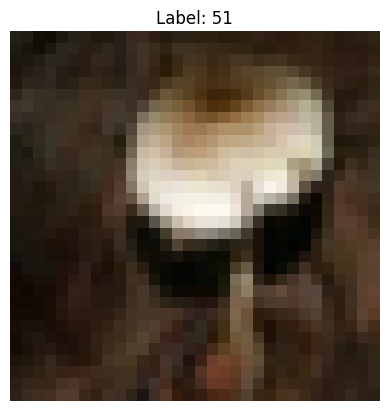

In [4]:
index = 1_000
show_img(x_train[index], y_train[index])

In [5]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_CNN_MODEL_PATH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_852 (Sequential)  (None, 16, 16, 64)       1984      
                                                                 
 sequential_853 (Sequential)  (None, 8, 8, 128)        222208    
                                                                 
 sequential_854 (Sequential)  (None, 4, 4, 128)        295936    
                                                                 
 sequential_855 (Sequential)  (None, 2, 2, 256)        295936    
                                                                 
 global_average_pooling2d_15  (None, 256)              0         
 3 (GlobalAveragePooling2D)                                      
                                                                 
 dropout_190 (Dropout)       (None, 256)               0         
                                                        

In [6]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 12s 23ms/step - loss: 3.5897 - accuracy: 0.1545 - val_loss: 4.8038 - val_accuracy: 0.0522
Epoch 2/100
313/313 [==============================] - 6s 20ms/step - loss: 2.7403 - accuracy: 0.2998 - val_loss: 3.1955 - val_accuracy: 0.2270
Epoch 3/100
313/313 [==============================] - 6s 20ms/step - loss: 2.2955 - accuracy: 0.3927 - val_loss: 2.8602 - val_accuracy: 0.2937
Epoch 4/100
313/313 [==============================] - 6s 20ms/step - loss: 2.0029 - accuracy: 0.4586 - val_loss: 2.4351 - val_accuracy: 0.3707
Epoch 5/100
313/313 [==============================] - 6s 20ms/step - loss: 1.7691 - accuracy: 0.5132 - val_loss: 2.5421 - val_accuracy: 0.3561
Epoch 6/100
313/313 [==============================] - 6s 20ms/step - loss: 1.5885 - accuracy: 0.5529 - val_loss: 2.6521 - val_accuracy: 0.3503
Epoch 7/100
313/313 [==============================] - 6s 20ms/step - loss: 1.4242 - accuracy: 0.5953 - val_loss: 2.2368 - val_accuracy

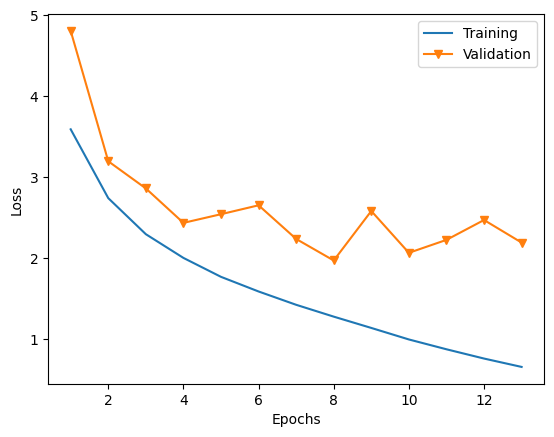

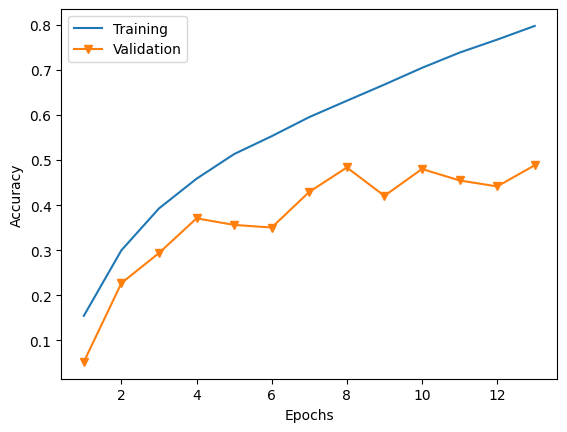

313/313 [==============================] - 2s 5ms/step - loss: 1.9020 - accuracy: 0.4949


[1.902001976966858, 0.4948999881744385]

In [7]:
plot_history(history)

model.evaluate(x_test, y_test)

## Hyperparameter-tuned DNN Model

In [3]:
feature_train, y_train, feature_val, y_val, feature_test, y_test = load_cifar100(return_features=True, verbose=0)

In [4]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_DNN_MODEL_PATH, use_loaded_opt=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_167 (Ba  (None, 2048)             8192      
 tchNormalization)                                               
                                                                 
 sequential_275 (Sequential)  (None, 1024)             2102272   
                                                                 
 sequential_276 (Sequential)  (None, 512)              526848    
                                                                 
 dropout_430 (Dropout)       (None, 512)               0         
                                                                 
 dense (Dense)               (None, 100)               51300     
                                                                 
Total params: 2,688,612
Trainable params: 2,681,444
Non-trainable params: 7,168
__________________________________________

In [5]:
history = model.fit(
    feature_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 8s 16ms/step - loss: 1.7118 - accuracy: 0.5498 - val_loss: 1.3166 - val_accuracy: 0.6443
Epoch 2/100
313/313 [==============================] - 5s 15ms/step - loss: 1.1231 - accuracy: 0.6753 - val_loss: 1.1436 - val_accuracy: 0.6686
Epoch 3/100
313/313 [==============================] - 4s 14ms/step - loss: 0.9347 - accuracy: 0.7224 - val_loss: 1.1227 - val_accuracy: 0.6726
Epoch 4/100
313/313 [==============================] - 4s 14ms/step - loss: 0.8108 - accuracy: 0.7558 - val_loss: 1.1232 - val_accuracy: 0.6790
Epoch 5/100
313/313 [==============================] - 4s 14ms/step - loss: 0.7092 - accuracy: 0.7843 - val_loss: 1.1244 - val_accuracy: 0.6822
Epoch 6/100
313/313 [==============================] - 4s 13ms/step - loss: 0.6258 - accuracy: 0.8089 - val_loss: 1.1332 - val_accuracy: 0.6847
Epoch 7/100
313/313 [==============================] - 4s 14ms/step - loss: 0.5500 - accuracy: 0.8288 - val_loss: 1.1419 - val_accuracy:

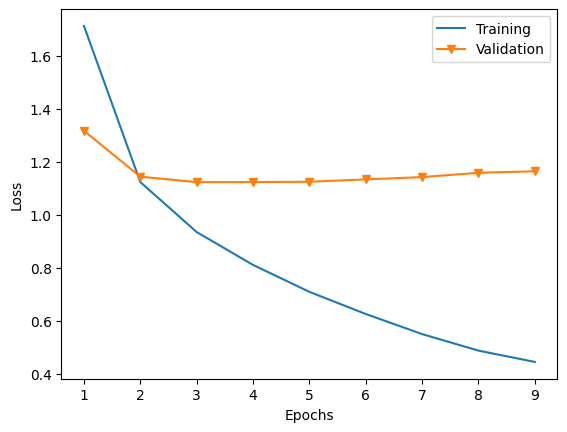

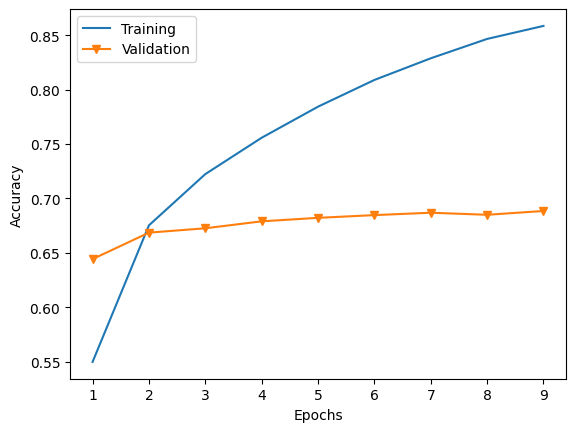

313/313 [==============================] - 1s 4ms/step - loss: 1.1457 - accuracy: 0.6804


[1.1457418203353882, 0.680400013923645]

In [6]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Transfer Learning with the pre-trained Xception Model

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar100(preprocess=False, verbose=0)

In [4]:
feature_train, feature_val, feature_test = extract_features(
    [x_train, x_val, x_test], 
    batch_size=BATCH_SIZE, 
    file_name="./data/cifar100_xception_gavgpooled_features_train_val_test"
)

79/79 [==============================] - 69s 885ms/step


In [5]:
feature_train, feature_val, feature_test = load_samples(
    "./data/cifar100_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

In [6]:
model = get_model(CLASS_NUM, model_type="DNN", dropout_rate=0.5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 100)               204900    
                                                                 
Total params: 204,900
Trainable params: 204,900
Non-trainable params: 0
_________________________________________________________________


In [7]:
history = model.fit(
    feature_train, y_train,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
1250/1250 [==============================] - 5s 3ms/step - loss: 1.8345 - accuracy: 0.5396 - val_loss: 1.3141 - val_accuracy: 0.6341
Epoch 2/100
1250/1250 [==============================] - 4s 3ms/step - loss: 1.2435 - accuracy: 0.6499 - val_loss: 1.2163 - val_accuracy: 0.6576
Epoch 3/100
1250/1250 [==============================] - 4s 3ms/step - loss: 1.1196 - accuracy: 0.6773 - val_loss: 1.1784 - val_accuracy: 0.6675
Epoch 4/100
1250/1250 [==============================] - 4s 3ms/step - loss: 1.0506 - accuracy: 0.6969 - val_loss: 1.1531 - val_accuracy: 0.6707
Epoch 5/100
1250/1250 [==============================] - 4s 3ms/step - loss: 1.0071 - accuracy: 0.7061 - val_loss: 1.1565 - val_accuracy: 0.6671
Epoch 6/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.9620 - accuracy: 0.7150 - val_loss: 1.1481 - val_accuracy: 0.6717
Epoch 7/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.9347 - accuracy: 0.7245 - val_loss: 1.1381 - val_ac

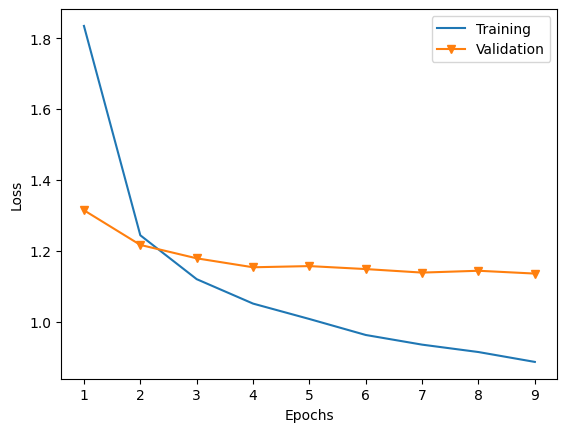

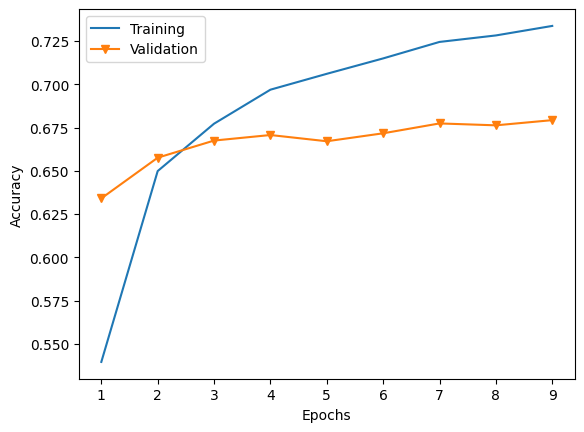

313/313 [==============================] - 1s 3ms/step - loss: 1.1438 - accuracy: 0.6737


[1.1437909603118896, 0.6736999750137329]

In [8]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Fine-tuning the pre-trained Xception Model

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar100(preprocess=False, verbose=0)

In [4]:
model = get_model(CLASS_NUM, model_type="pretrained", num_last_not_frozen=12, dropout_rate=0.50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resize (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 xception_preprocess (Lambda  (None, 299, 299, 3)      0         
 )                                                               
                                                                 
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 100)               2

In [5]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 415s 1s/step - loss: 1.3690 - accuracy: 0.6281 - val_loss: 1.0192 - val_accuracy: 0.7040
Epoch 2/100
313/313 [==============================] - 397s 1s/step - loss: 0.7399 - accuracy: 0.7774 - val_loss: 0.9642 - val_accuracy: 0.7252
Epoch 3/100
313/313 [==============================] - 398s 1s/step - loss: 0.4900 - accuracy: 0.8483 - val_loss: 1.0040 - val_accuracy: 0.7247
Epoch 4/100
313/313 [==============================] - 398s 1s/step - loss: 0.3138 - accuracy: 0.8999 - val_loss: 1.0366 - val_accuracy: 0.7234
Epoch 5/100
313/313 [==============================] - 390s 1s/step - loss: 0.1965 - accuracy: 0.9392 - val_loss: 1.0904 - val_accuracy: 0.7392
Epoch 6/100
313/313 [==============================] - 381s 1s/step - loss: 0.1326 - accuracy: 0.9591 - val_loss: 1.1674 - val_accuracy: 0.7311
Epoch 7/100
313/313 [==============================] - 380s 1s/step - loss: 0.1130 - accuracy: 0.9649 - val_loss: 1.2149 - val_accuracy:

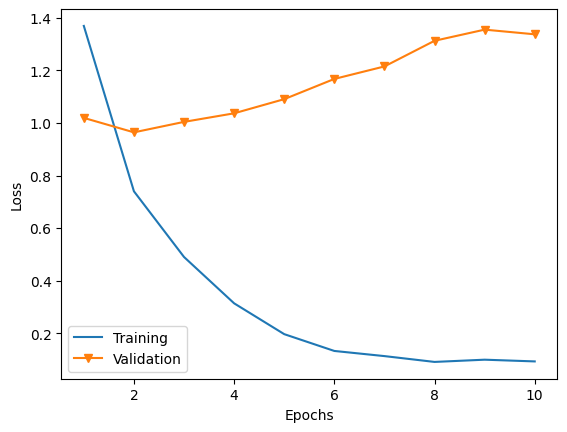

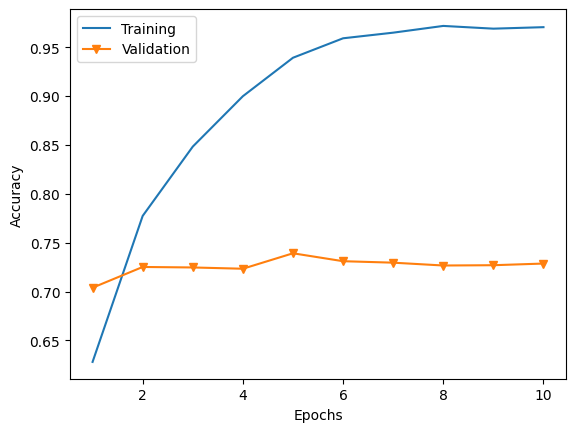

313/313 [==============================] - 71s 218ms/step - loss: 1.0719 - accuracy: 0.7397


[1.0718823671340942, 0.7397000193595886]

In [6]:
plot_history(history)

model.evaluate(x_test, y_test)

# Continual Learning

## Continually adding classes to different models

### CNN Model

In [ ]:
acc_list1 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar100, 
    keep_same_model=False, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

In [ ]:
acc_list2 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar100, 
    keep_same_model=False, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model

### CNN Model

In [ ]:
acc_list3 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar100, 
    keep_same_model=True, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

In [ ]:
acc_list4 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar100, 
    keep_same_model=True, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model without the previous data

### CNN Model

In [ ]:
acc_list5 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar100, 
    keep_same_model=True, 
    remove_prev_classes=True, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

In [ ]:
from tensorflow.keras import optimizers

from filtered_loss import FilteredLoss
from utils import get_compile_args


acc_list6 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar100, 
    keep_same_model=True, 
    remove_prev_classes=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    onehot_labels=True,
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=FilteredLoss()
    )
)

## Conclusion

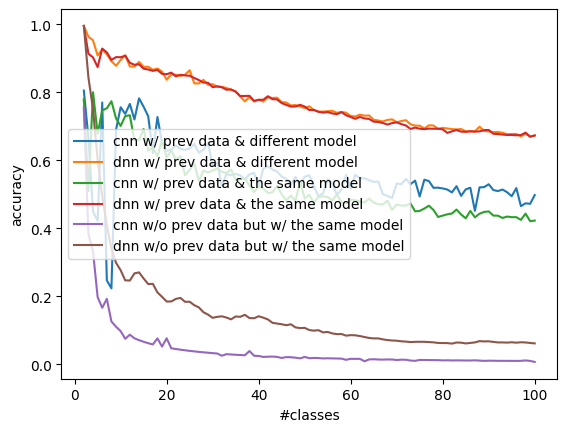

In [9]:
CL_plot(CLASS_NUM, 
    [
    (acc_list1, "cnn w/ prev data & different model"), 
    (acc_list2, "dnn w/ prev data & different model"), 
    (acc_list3, "cnn w/ prev data & the same model"), 
    (acc_list4, "dnn w/ prev data & the same model"), 
    (acc_list5, "cnn w/o prev data but w/ the same model"), 
    (acc_list6, "dnn w/o prev data but w/ the same model"), 
    ]
)